In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import pickle

In [2]:
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [3]:
data=sns.load_dataset ('taxis')

In [4]:
data.head()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


In [5]:
data.sample(5)

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
1976,2019-03-02 14:55:32,2019-03-02 15:10:48,1,1.66,11.0,2.86,0.0,17.16,yellow,credit card,Midtown North,Penn Station/Madison Sq West,Manhattan,Manhattan
1545,2019-03-13 20:17:05,2019-03-13 20:21:35,1,0.90,5.5,1.85,0.0,11.15,yellow,credit card,Midtown East,Sutton Place/Turtle Bay North,Manhattan,Manhattan
6102,2019-03-03 00:39:49,2019-03-03 01:00:18,1,3.74,16.0,5.19,0.0,22.49,green,credit card,Williamsburg (South Side),Sunnyside,Brooklyn,Queens
3525,2019-03-29 20:48:40,2019-03-29 21:12:42,1,5.47,20.0,3.57,0.0,29.32,yellow,credit card,Long Island City/Hunters Point,Upper West Side South,Queens,Manhattan
241,2019-03-29 13:30:12,2019-03-29 13:36:35,1,1.23,6.5,2.45,0.0,12.25,yellow,credit card,Manhattan Valley,Upper West Side North,Manhattan,Manhattan


In [6]:
data.shape

(6433, 14)

In [7]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6433 non-null   datetime64[us]
 1   dropoff          6433 non-null   datetime64[us]
 2   passengers       6433 non-null   int64         
 3   distance         6433 non-null   float64       
 4   fare             6433 non-null   float64       
 5   tip              6433 non-null   float64       
 6   tolls            6433 non-null   float64       
 7   total            6433 non-null   float64       
 8   color            6433 non-null   str           
 9   payment          6389 non-null   str           
 10  pickup_zone      6407 non-null   str           
 11  dropoff_zone     6388 non-null   str           
 12  pickup_borough   6407 non-null   str           
 13  dropoff_borough  6388 non-null   str           
dtypes: datetime64[us](2), float64(5), int64(1), str(6)


In [8]:
data.describe()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total
count,6433,6433,6433.000000,6433.000000,6433.000000,6433.00000,6433.000000,6433.000000
mean,2019-03-16 08:31:28.514223,2019-03-16 08:45:49.491216,1.539251,3.024617,13.091073,1.97922,0.325273,18.517794
min,2019-02-28 23:29:03,2019-02-28 23:32:35,0.000000,0.000000,1.000000,0.00000,0.000000,1.300000
25%,2019-03-08 15:50:34,2019-03-08 16:12:51,1.000000,0.980000,6.500000,0.00000,0.000000,10.800000
50%,2019-03-15 21:46:58,2019-03-15 22:06:44,1.000000,1.640000,9.500000,1.70000,0.000000,14.160000
75%,2019-03-23 17:41:38,2019-03-23 17:51:56,2.000000,3.210000,15.000000,2.80000,0.000000,20.300000
max,2019-03-31 23:43:45,2019-04-01 00:13:58,6.000000,36.700000,150.000000,33.20000,24.020000,174.820000
std,NaN,NaN,1.203768,3.827867,11.551804,2.44856,1.415267,13.815570


In [9]:
data.isna().sum()

pickup              0
dropoff             0
passengers          0
distance            0
fare                0
tip                 0
tolls               0
total               0
color               0
payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64

In [10]:
original_columns = data.columns
imput=SimpleImputer(fill_value=np.nan,strategy='most_frequent')

In [11]:
data.iloc[:,8:]=imput.fit_transform(data.iloc[:,8:])


In [12]:
data.isna().sum()

pickup             0
dropoff            0
passengers         0
distance           0
fare               0
tip                0
tolls              0
total              0
color              0
payment            0
pickup_zone        0
dropoff_zone       0
pickup_borough     0
dropoff_borough    0
dtype: int64

In [13]:
data.head()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


<Axes: >

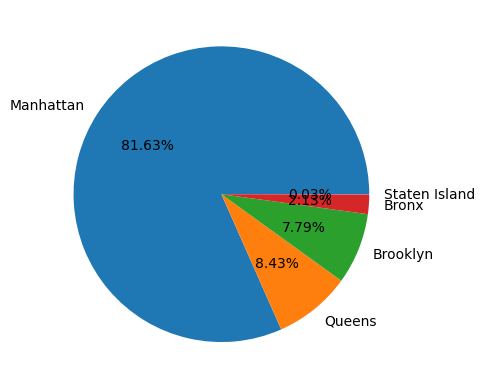

In [14]:
data['dropoff_borough'].value_counts().plot(kind='pie',autopct='%.2f%%')

<Axes: >

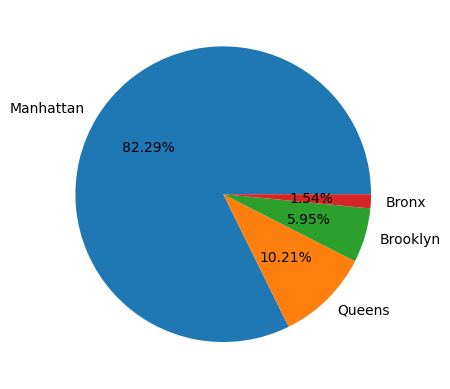

In [15]:
data['pickup_borough'].value_counts().plot(kind='pie',autopct='%.2f%%')

<Axes: >

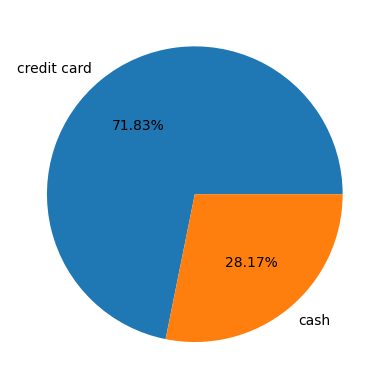

In [16]:
data['payment'].value_counts().plot(kind='pie',autopct='%.2f%%')

In [17]:
data1=data['pickup_zone'].values[:50]


data1

<ArrowStringArray>
[              'Lenox Hill West',         'Upper West Side South',
                 'Alphabet City',                     'Hudson Sq',
                  'Midtown East',     'Times Sq/Theatre District',
             'Battery Park City',                   'Murray Hill',
             'East Harlem South',           'Lincoln Square East',
             'LaGuardia Airport',         'Upper West Side South',
                   'Murray Hill',           'Lincoln Square West',
      'Financial District North',         'Upper West Side North',
                  'East Chelsea',                'Midtown Center',
                      'Gramercy',                  'East Chelsea',
  'Penn Station/Madison Sq West',  'Penn Station/Madison Sq West',
             'LaGuardia Airport', 'Sutton Place/Turtle Bay North',
               'Lenox Hill West',           'Lincoln Square East',
     'West Chelsea/Hudson Yards',                  'Clinton East',
                  'Clinton West',          

<Axes: >

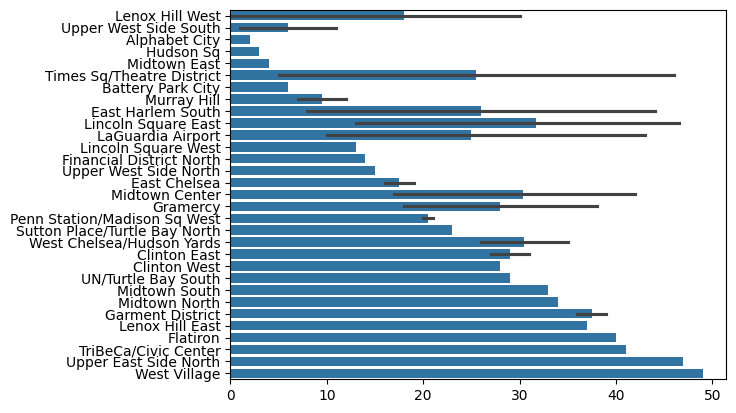

In [18]:
sns.barplot(data1)

<Axes: >

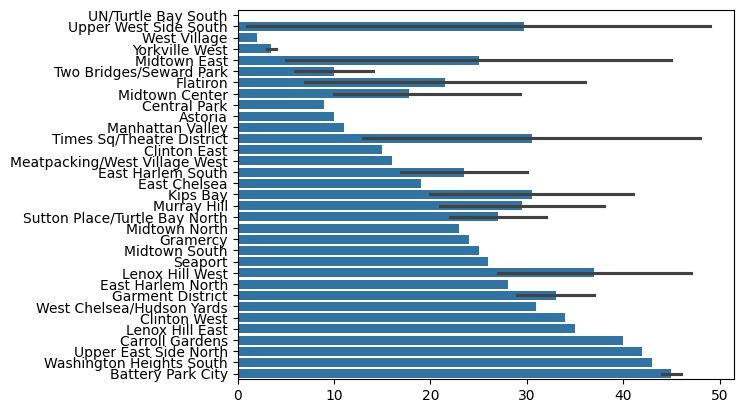

In [19]:
data2=data['dropoff_zone'].values[:50]

sns.barplot(data2 )

<Axes: ylabel='color'>

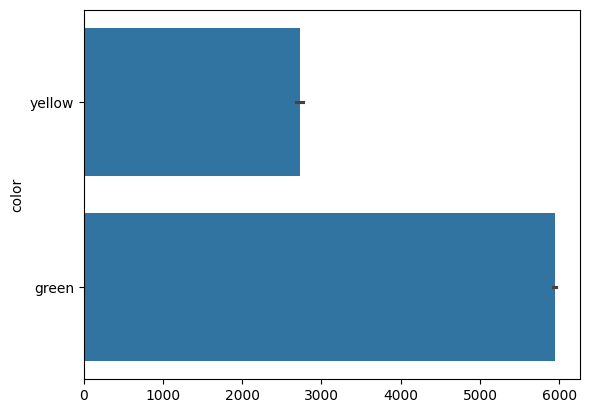

In [20]:
sns.barplot(data['color'])

In [22]:
# Clean up target column just in case
data = data.dropna(subset=['dropoff_borough'])

# Define Target (y)
y = data['dropoff_borough']

# Select Features (X) - Data known at the start of the ride
selected_features = ['pickup_borough', 'distance', 'fare', 'passengers']
X = data[selected_features]

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data: {X_train.shape[0]} rows")
print(f"Testing data: {X_test.shape[0]} rows")

Training data: 5146 rows
Testing data: 1287 rows


In [24]:
# Setup the preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ['pickup_borough']),
        ('num', StandardScaler(), ['distance', 'fare', 'passengers'])
    ]
)

# Fit and transform the training data
X_train_processed = preprocessor.fit_transform(X_train)

# ONLY transform the testing data (do not fit here!)
X_test_processed = preprocessor.transform(X_test)

print("Data is encoded and standardized.")

Data is encoded and standardized.


<Axes: >

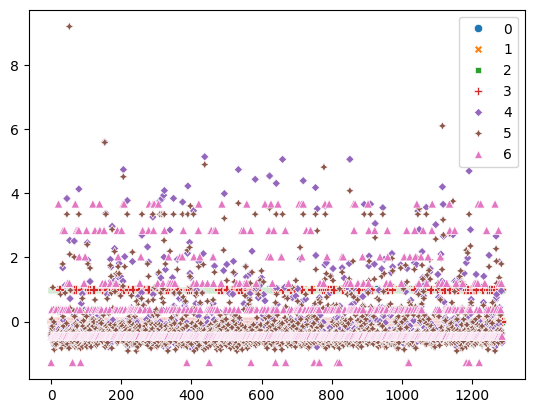

In [29]:
sns.scatterplot(X_test_processed)

In [52]:
# (Optional) If you want to see the new column names:
encoded_columns = preprocessor.get_feature_names_out()
X_train_df = pd.DataFrame(X_train_encoded, columns=encoded_columns)



In [53]:
print(X_train_df.head())

  encoder__pickup_borough_Bronx encoder__pickup_borough_Brooklyn  \
0                           0.0                              0.0   
1                           0.0                              0.0   
2                           0.0                              1.0   
3                           0.0                              0.0   
4                           0.0                              0.0   

  encoder__pickup_borough_Manhattan encoder__pickup_borough_Queens  \
0                               1.0                            0.0   
1                               1.0                            0.0   
2                               0.0                            0.0   
3                               1.0                            0.0   
4                               1.0                            0.0   

  remainder__distance remainder__fare remainder__passengers  
0                 5.5            20.0                     2  
1                0.54             4.0         

In [32]:
model=LogisticRegression(max_iter=1000)
model.fit(X_train_processed,y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [33]:
# Make predictions on the unseen test set
y_pred = model.predict(X_test_processed)

# Calculate the overall accuracy percentage
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")

# Print a detailed report showing precision and recall for every borough
print(classification_report(y_test, y_pred))

Model Accuracy: 87.33%

              precision    recall  f1-score   support

       Bronx       0.59      0.48      0.53        27
    Brooklyn       0.77      0.52      0.62        89
   Manhattan       0.92      0.94      0.93      1056
      Queens       0.54      0.59      0.56       115

    accuracy                           0.87      1287
   macro avg       0.70      0.63      0.66      1287
weighted avg       0.87      0.87      0.87      1287



In [34]:
import pickle

# Save the preprocessor
with open('taxi_preprocessor.pkl', 'wb') as f:
    pickle.dump(preprocessor, f)

# Save the model
with open('taxi_model.pkl', 'wb') as f:
    pickle.dump(model, f)

print("Saved successfully using Pickle!")

Saved successfully using Pickle!


In [35]:

# 1. Load the tools back into memory
with open('taxi_preprocessor.pkl', 'rb') as f:
    loaded_preprocessor = pickle.load(f)

with open('taxi_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

# 2. Get live input directly from the user
print("\n --- Enter Taxi Ride Details --- ")
user_pickup = input("Enter Pickup Borough (e.g., Manhattan, Queens, Brooklyn, Bronx): ")
user_distance = float(input("Enter Distance in miles (e.g., 4.5): "))
user_fare = float(input("Enter Fare amount in dollars (e.g., 25.00): "))
user_passengers = int(input("Enter Number of Passengers (e.g., 2): "))

# 3. Format the user's input into a Pandas DataFrame
# The column names must exactly match what the model trained on
real_trip_data = pd.DataFrame([{
    'pickup_borough': user_pickup,
    'distance': user_distance,
    'fare': user_fare,
    'passengers': user_passengers
}])

# 4. Process the data and Predict
processed_trip = loaded_preprocessor.transform(real_trip_data)
prediction = loaded_model.predict(processed_trip)

# 5. Show the result
print("\n" + "="*40)
print(f" Prediction: The dropoff will likely be in {prediction[0]}")
print("="*40 + "\n")


 --- Enter Taxi Ride Details --- 

 Prediction: The dropoff will likely be in Manhattan

